# 🎮 **EDA – Venta de videojuegos y su rating (1976–2017)** 🎮

**Objetivo:** entender qué factores se asocian con mayores ventas (globales y por región) y qué “pesa más” en el rendimiento comercial: **crítica profesional** vs **usuarios**, además de identificar **patrones de mercado** (géneros, plataformas, publishers, ESRB y concentración).

## 0) Setup e importaciones

In [1]:
import pandas as pd
from src.utils.funciones import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 200)

# Rutas
RAW_DATA_PATH = "./src/data/raw/Video_Game_Sales_as_of_Jan_2017.csv"
CLEAN_DATA_PATH = "./src/data/processed/video_game_sales_limpio.csv"

## 1) Carga de datos

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (17416, 15)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN


In [3]:
#Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17408 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17415 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     8336 non-null   float64
 11  Critic_Count     8336 non-null   float64
 12  User_Score       7798 non-null   float64
 13  User_Count       7798 non-null   float64
 14  Rating           10252 non-null  object 
dtypes: float64(10), object(5)
memory usage: 2.0+ MB


### 1.1 Diccionario rápido de variables
- Ventas: `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, `Global_Sales` *(millones de unidades)*
- Percepción: `Critic_Score` (0–100), `User_Score` (0–10 en origen), `Critic_Count`, `User_Count`
- Negocio: `Genre`, `Platform`, `Publisher`, `Rating`, `Year_of_Release`

## 2) Calidad de datos y limpieza
En este dataset hay **muchos faltantes** en las variables de percepción y ESRB.  
La estrategia aquí es:

- **No imputar scores** (evitamos inventar señal).
- Crear **variables derivadas** y **submuestras** para análisis comparables.
- Ser transparentes con limitaciones y sesgos (ej.: filtrar por `User_Count` cambia el tipo de juego observado).

### 2.1 Presencia de nulos

In [4]:
#Comprobamos los nulos tras la conversión
df.isnull().sum()

Name                  0
Platform              0
Year_of_Release       8
Genre                 0
Publisher             1
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       9080
Critic_Count       9080
User_Score         9618
User_Count         9618
Rating             7164
dtype: int64

In [5]:
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
missing.to_frame("missing_%")

,missing_%
User_Count,55.2
User_Score,55.2
Critic_Score,52.1
Critic_Count,52.1
Rating,41.1
Year_of_Release,0.0
Publisher,0.0
EU_Sales,0.0
NA_Sales,0.0
Genre,0.0


Las columnas `Year_of_Release` y `Publisher` se eliminan sus nulos debido a la presencia de muy pocos de ellos. Las columnas `Critic_Score`, `Critic_Count`, `User_Score`, `User_Count` y `Rating` mantenemos las columnas como están pero hacemos tres columnas flags para indicar si tiene o no el dato.

- `Critica_Profesional`: Sí/No si tiene dato de `Critic_Score` y `Critic_Count`.
- `Critica_Usuario`: Sí/No si tiene dato de `Critic_Score` y `Critic_Count`.
- `Tiene_Rating`: Sí/No si tiene dato de `Rating`.

In [6]:
df_clean = limpiar_df(df)

### 2.2 Presencia de duplicados

In [7]:
df_clean.duplicated().sum()

np.int64(0)

No hay presencia de duplicados en nuestro dataset.

### 2.3 Visualización de los datos limpios

In [8]:
df_clean.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating,Critica_Profesional,Critica_Usuario,Tiene_Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E,Sí,Sí,Sí
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,No,No,No
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E,Sí,Sí,Sí
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E,Sí,Sí,Sí
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,No,No,No


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17408 entries, 0 to 17415
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 17408 non-null  object 
 1   Platform             17408 non-null  object 
 2   Year_of_Release      17408 non-null  float64
 3   Genre                17408 non-null  object 
 4   Publisher            17408 non-null  object 
 5   NA_Sales             17408 non-null  float64
 6   EU_Sales             17408 non-null  float64
 7   JP_Sales             17408 non-null  float64
 8   Other_Sales          17408 non-null  float64
 9   Global_Sales         17408 non-null  float64
 10  Critic_Score         8335 non-null   float64
 11  Critic_Count         8335 non-null   float64
 12  User_Score           7798 non-null   float64
 13  User_Count           7798 non-null   float64
 14  Rating               10250 non-null  object 
 15  Critica_Profesional  17408 non-null  obje

### 2.4 Submuestras para visibilizar los juegos con score
No todos los juegos tienen el mismo nivel de información disponible ni el mismo grado de participación de los usuarios.

In [10]:
resumen_scores(df_clean)

Total: 17408
Con al menos algún score: 8942
Con ambos scores: 7191
High engagement (User_Count>=50): 2620


{'df_scores':                                                    Name Platform  Year_of_Release         Genre  \
 0                                            Wii Sports      Wii           2006.0        Sports   
 1                                     Super Mario Bros.      NES           1985.0      Platform   
 2                                        Mario Kart Wii      Wii           2008.0        Racing   
 3                                     Wii Sports Resort      Wii           2009.0        Sports   
 4                              Pokemon Red/Pokemon Blue        G           1996.0  Role-Playing   
 ...                                                 ...      ...              ...           ...   
 17411  Nancy Drew: The Deadly Secret of Olde World Park       DS           2007.0     Adventure   
 17412                      Fashion Designer: Style Icon       DS           2007.0    Simulation   
 17413            Ashita no Joe 2: The Anime Super Remix      PS2           2002.0     

### 2.5 Guardado de los datos

In [11]:
df_clean.to_csv("./src/data/video_game_sales_limpio.csv", index=False)

## 3) Análisis exploratorio de los datos

### 3.1 Cargamos los datos limpios, por si la parte anterior no la quisieramos realizar

In [12]:
df_clean = pd.read_csv(CLEAN_DATA_PATH)
print("Shape:", df_clean.shape)
df_clean.head()

Shape: (15437, 19)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating,Critica_Profesional,Critica_Usuario,Tiene_Rating,Global_Sales_norm
0,LEGO The Lord of the Rings,PS3,2012.0,Action,Warner Bros. Interactive Entertainment,0.37,0.49,0.00,0.19,1.05,82.0,16.0,8.3,85.0,E10+,Sí,Sí,Sí,1.0
1,EA Sports UFC,PS4,2014.0,Sports,Electronic Arts,0.46,0.41,0.01,0.18,1.05,70.0,57.0,6.1,280.0,T,Sí,Sí,Sí,1.0
2,Sega Superstars Tennis,Wii,2008.0,Sports,Sega,0.28,0.65,0.00,0.13,1.05,71.0,24.0,6.8,17.0,E10+,Sí,Sí,Sí,1.0
3,DiRT,PS3,2007.0,Racing,Codemasters,0.16,0.66,0.00,0.23,1.05,83.0,32.0,8.0,33.0,E,Sí,Sí,Sí,1.0
4,Call of Duty 4: Modern Warfare,DS,2007.0,Shooter,Activision,0.95,0.01,0.01,0.08,1.05,75.0,22.0,6.9,36.0,T,Sí,Sí,Sí,1.0


### 3.2 Panorama del mercado (ventas y regiones)

Gráfico guardado: ./src/img\distribucion_ventas_globales.jpg


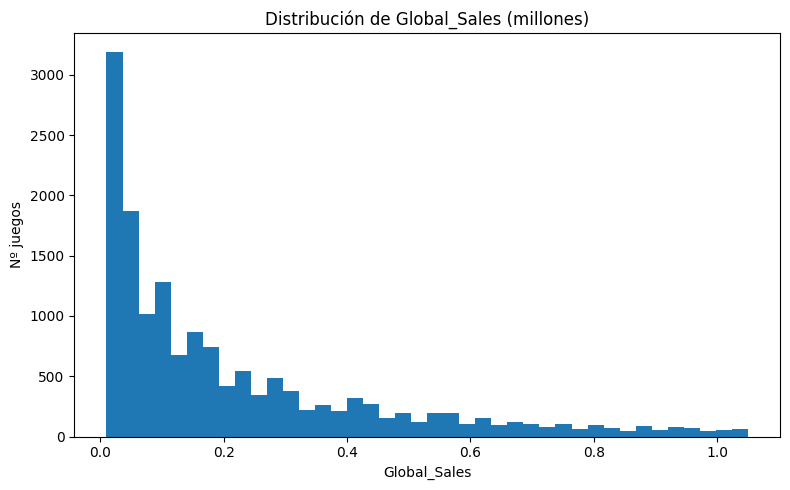

Gráfico guardado: ./src/img\distribucion_ventas_log.jpg


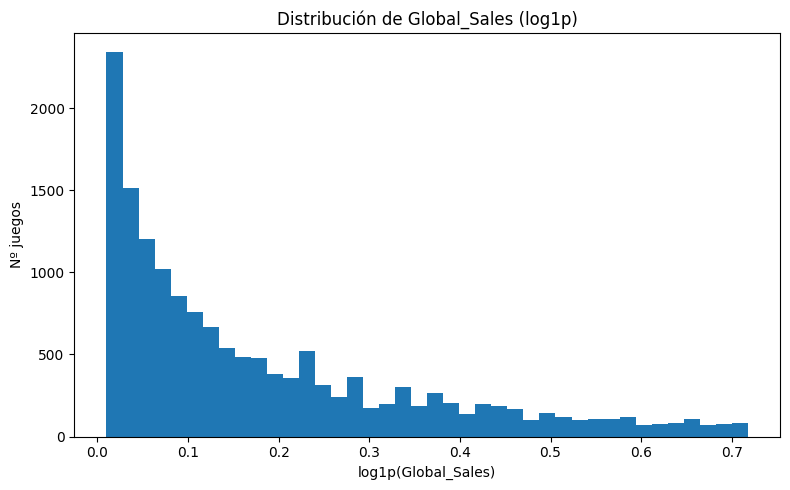

Gráfico guardado: ./src/img\ventas_por_region.jpg


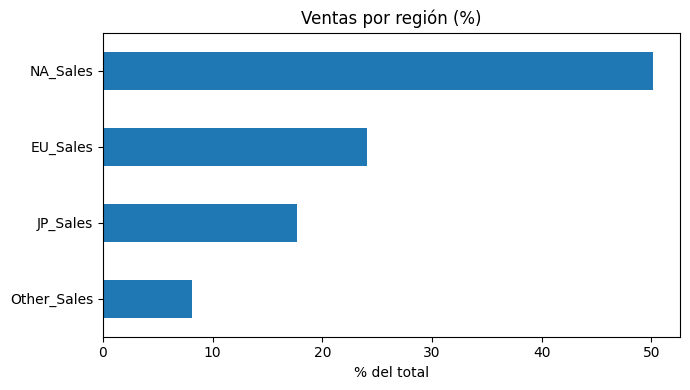

In [13]:
df_panorama, region_share = panorama_mercado(df_clean)

### **3.3 HIPÓTESIS 1:** Evolución e impacto de las valoraciones y reseñas en el rendimiento comercial

#### 3.3.1 Relación entre la crítica profesional y las ventas

La correlación entre la crítica y las ventas globales es: 0.26
Interpretación: correlación débil
Gráfico guardado: ./src/img\correlacion_Critic_Score.jpg


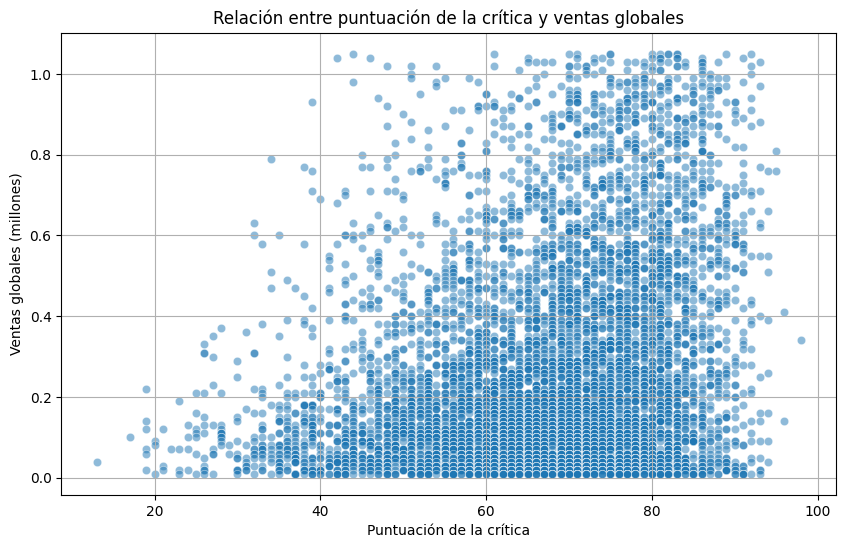

In [14]:
correlacion_criticos = analizar_correlacion(df_clean, "Critic_Score")

El gráfico de dispersión revela una correlación positiva pero leve. Observamos que, si bien una puntuación alta de la crítica (eje X > 80) facilita las ventas, no es una garantía de éxito masivo. Existen numerosos títulos con puntuaciones excelentes que no lograron despuntar comercialmente (falsos positivos de calidad). Sin embargo, actúa como un filtro de seguridad: es muy raro ver un "superventas" con una puntuación crítica desastrosa.

#### 3.3.2 Relación entre la valoración del usuario y las ventas

La correlación entre la crítica y las ventas globales es: 0.10
Interpretación: correlación muy débil o inexistente
Gráfico guardado: ./src/img\correlacion_User_Score.jpg


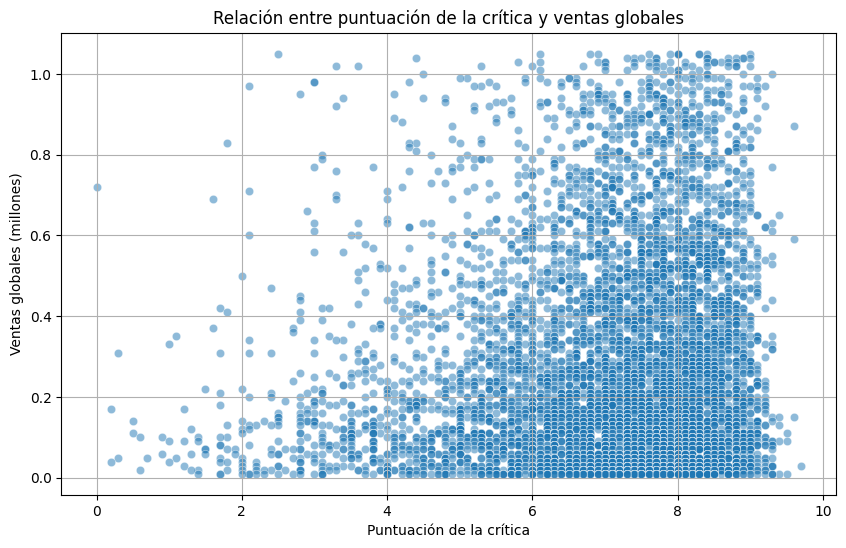

In [15]:
correlacion_usuarios = analizar_correlacion(df_clean, "User_Score")

Gráfico guardado: ./src/img\comparativa_correlaciones_barras.jpg


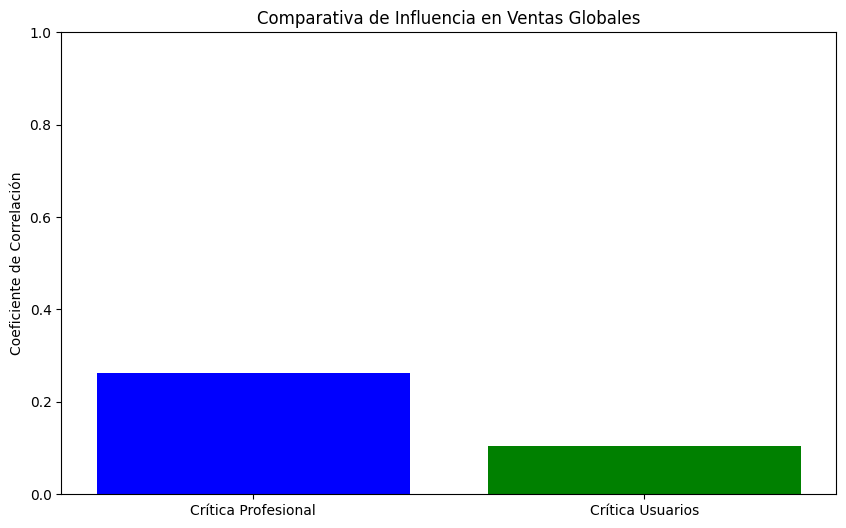

In [16]:
comparar_correlaciones(correlacion_criticos, correlacion_usuarios)

Al comparar ambas métricas, descubrimos un hallazgo crucial: La correlación de ventas con los usuarios es significativamente menor que con la crítica profesional. Esto sugiere que las ventas masivas ("Blockbusters") están impulsadas principalmente por el marketing y la recepción de la prensa especializada. La opinión del usuario, a menudo polarizada o reactiva, tiene menos peso en el volumen final de ventas.

#### 3.3.3 La Brecha de opinión: Disonancia entre la crítica profesional y los usuarios

Correlación Ventas Globales vs Critic Score: 0.2620
Estadísticas de la Brecha (Score_dif):
count    5920.000000
mean       -2.688176
std        12.830239
min       -62.000000
25%       -10.000000
50%        -3.000000
75%         4.000000
max        66.000000
Name: Score_dif, dtype: float64
Gráfico guardado: ./src/img\brecha_scores_Todos_los_juegos.jpg


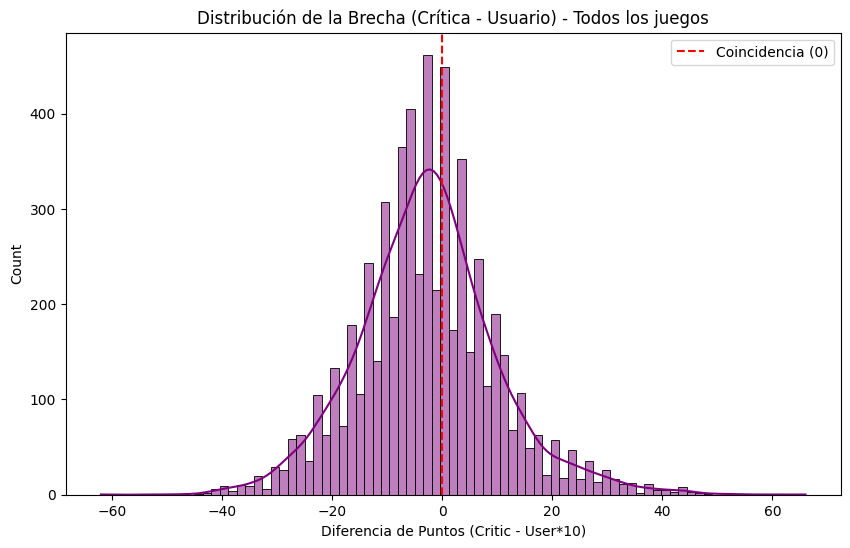

In [17]:
analizar_brecha_scores(df_clean, titulo="Todos los juegos")

La distribución de la brecha de puntuación (Crítica - Usuario) muestra un ligero sesgo hacia valores negativos, lo que indica una tendencia general de los usuarios a otorgar calificaciones más altas que la prensa especializada. Mientras que el grueso de los datos se concentra cerca del equilibrio, la asimetría en el lado izquierdo, especialmente entre los -10 y -30 puntos, resalta casos donde la recepción del público fue notablemente mejor que la de los críticos. Por el contrario, la cola derecha representa títulos que no lograron conectar con la audiencia pese al respaldo de la industria. Es importante considerar que los valores extremos en ambos sentidos podrían estar influenciados por muestras de críticas poco representativas en ciertos títulos.

Así pues, se decidió reanalizar de nuevo pero con aquellos juegos que tenían más de 50 valoraciones, para marcar un corte.

In [18]:
df_filtrado = df_clean[df_clean["User_Count"] >= 50].copy()

print("-" * 50)
print(f"Juegos antes del filtro: {len(df_clean)}")
print(f"Juegos después del filtro (>= 50 votos): {len(df_filtrado)}")

--------------------------------------------------
Juegos antes del filtro: 15437
Juegos después del filtro (>= 50 votos): 1702


Correlación Ventas Globales vs Critic Score: 0.1656
Estadísticas de la Brecha (Score_dif):
count    1659.000000
mean        2.217601
std        11.728545
min       -41.000000
25%        -4.500000
50%         1.000000
75%         8.000000
max        59.000000
Name: Score_dif, dtype: float64
Gráfico guardado: ./src/img\brecha_scores_Juegos_con_más_de_50_votos.jpg


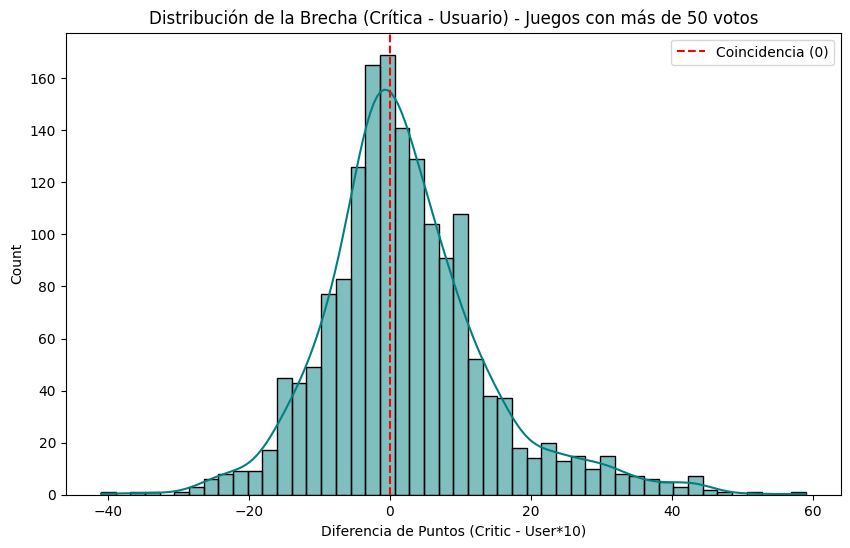

In [20]:
analizar_brecha_scores(df_filtrado, titulo="Juegos con más de 50 votos", color_grafico='teal')

Al filtrar el conjunto de datos para incluir únicamente títulos con 50 o más reseñas, se observa una reducción significativa del "ruido" estadístico provocado por valoraciones poco representativas. Tras este ajuste, la distribución de la brecha entre críticos y usuarios muestra una desviación más moderada y equilibrada, confirmando que gran parte de las disparidades extremas iniciales eran producto de muestras insuficientes. Al eliminar estos valores atípicos, el análisis restante se vuelve más realista, permitiendo identificar tendencias de opinión más sólidas y fundamentadas en un volumen de interacción significativo.

#### 3.3.4 Influencia del volumen de valoraciones con respecto a las ventas

La correlación entre la crítica y las ventas globales es: 0.33
Interpretación: correlación débil
Gráfico guardado: ./src/img\correlacion_Critic_Count.jpg


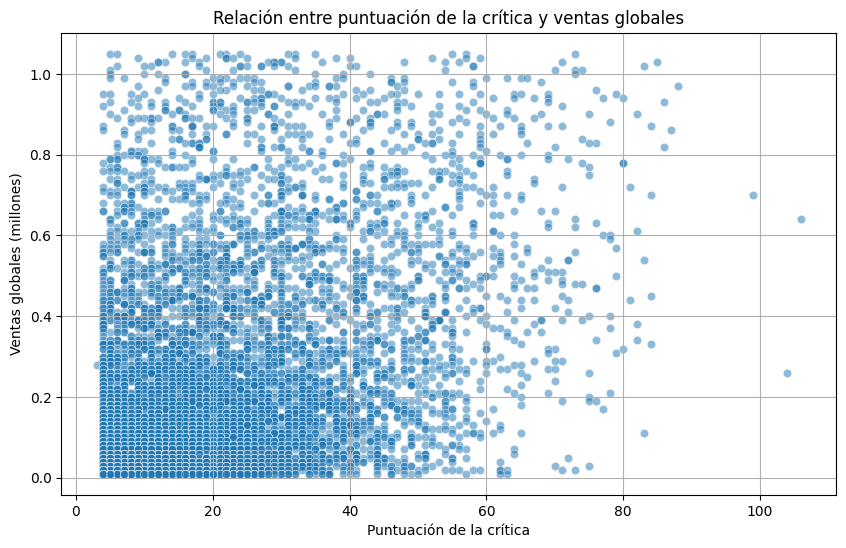

In [21]:
corr_vol_criticos = analizar_correlacion(df_clean, "Critic_Count")

La correlación entre la crítica y las ventas globales es: 0.10
Interpretación: correlación muy débil o inexistente
Gráfico guardado: ./src/img\correlacion_User_Count.jpg


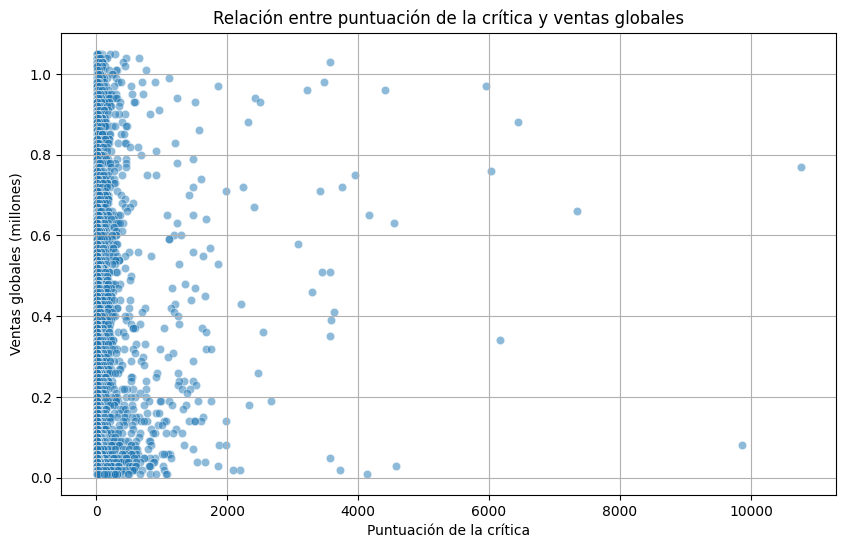

In [22]:
corr_vol_usuarios = analizar_correlacion(df_clean, "User_Count")

Se observa una correlación moderada entre el volumen de ventas y el número de reseñas realizadas por la crítica especializada. Este vínculo responde, probablemente, a que los títulos con mayores cifras de ventas suelen contar con campañas de marketing más robustas y una cobertura mediática más extensa. No obstante, esta relación no se traslada al ámbito del público general, donde la correlación entre las ventas y el volumen de críticas de los usuarios es prácticamente nula. Esto sugiere que el éxito comercial de un juego no garantiza necesariamente un alto nivel de participación o interacción activa por parte de la comunidad de jugadores en la plataforma. Un juego que genera conversación, sea positiva o negativa, tiende a vender más que uno con buenas notas pero ignorado por la comunidad.

#### 3.3.5 Evolución temporal de la cantidad y calidad de las valoraciones y la brecha entre la crítica del usuario y el profesional a lo largo de los años (1995-2016)

Gráfico guardado: ./src/img\evolucion_temporal_full.jpg


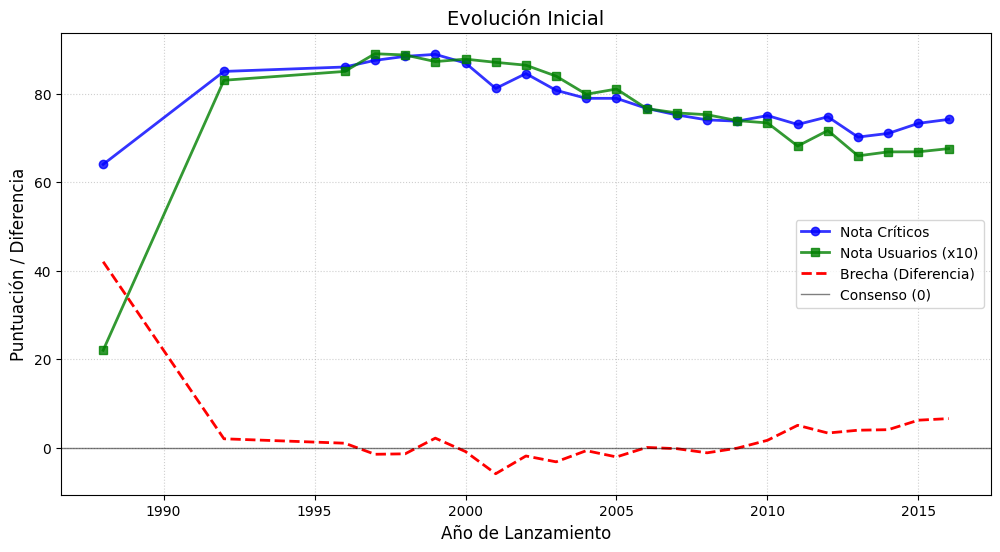

In [24]:
visualizar_evolucion_temporal(df_filtrado, titulo="Evolución Inicial")

In [25]:
auditar_anio(df_filtrado, 1988)


--- Auditoría del año 1988 ---
Total juegos encontrados: 1
          Name  User_Score  Critic_Score  User_Count
12739  SimCity         2.2          64.0      4578.0


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating,Critica_Profesional,Critica_Usuario,Tiene_Rating,Global_Sales_norm
12739,SimCity,PC,1988.0,Simulation,Maxis,0.0,0.02,0.0,0.01,0.03,64.0,75.0,2.2,4578.0,E10+,Sí,Sí,Sí,0.019231


Gráfico guardado: ./src/img\evolucion_temporal_1995.jpg


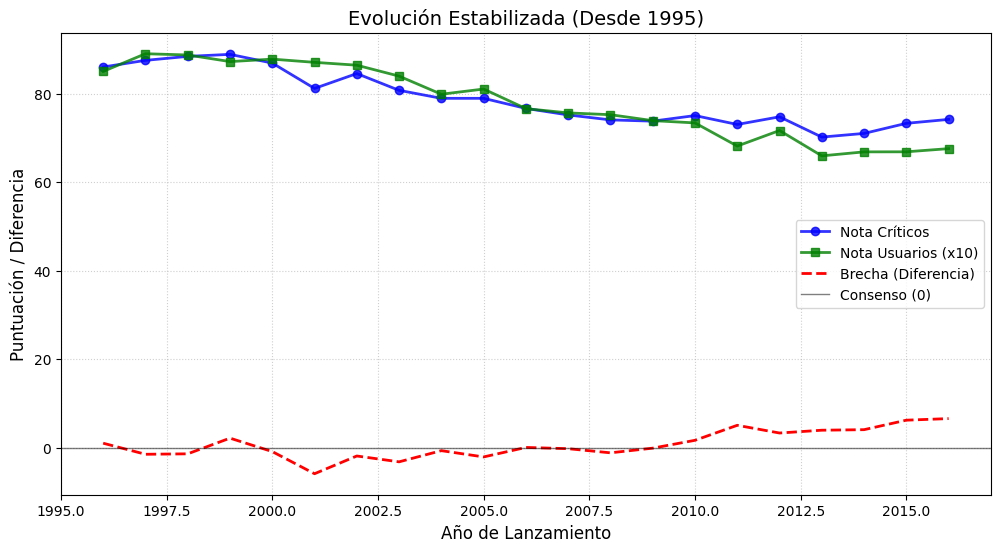

In [26]:
visualizar_evolucion_temporal(df_filtrado, start_year=1995, titulo="Evolución Estabilizada")

A medida que la industria ha madurado y se ha saturado de lanzamientos, se observa una ligera tendencia bajista en las puntuaciones medias, acompañada de una brecha persistente entre críticos y usuarios durante la última década. Este fenómeno sugiere un cambio en la dinámica del mercado donde el consenso histórico se ha debilitado, reflejando que los criterios de la prensa y las expectativas del público divergen cada vez más. Si bien esta disparidad parece haberse estabilizado a partir de 2010, el escenario actual revela un mercado más exigente donde la falta de acuerdo entre ambos grupos es ahora una característica estructural del sector.

### **3.4 HIPÓTESIS 2:** Dominio del mercado de los videojuegos

#### 3.4.1 Rentabilidad de los videojuegos por género

Gráfico guardado: ./src/img\ventas_totales_genero.jpg


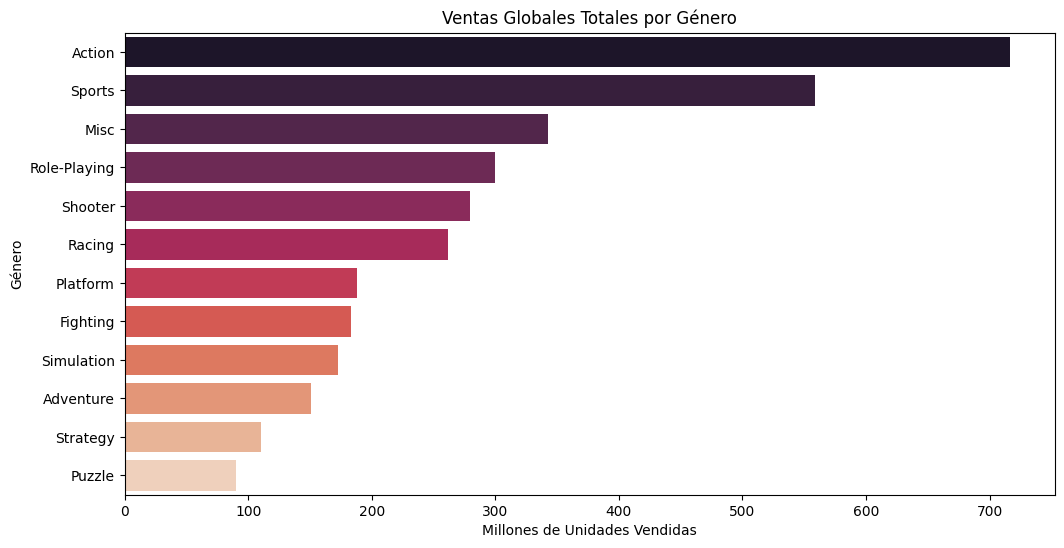

Gráfico guardado: ./src/img\ventas_promedio_eficiencia_genero.jpg


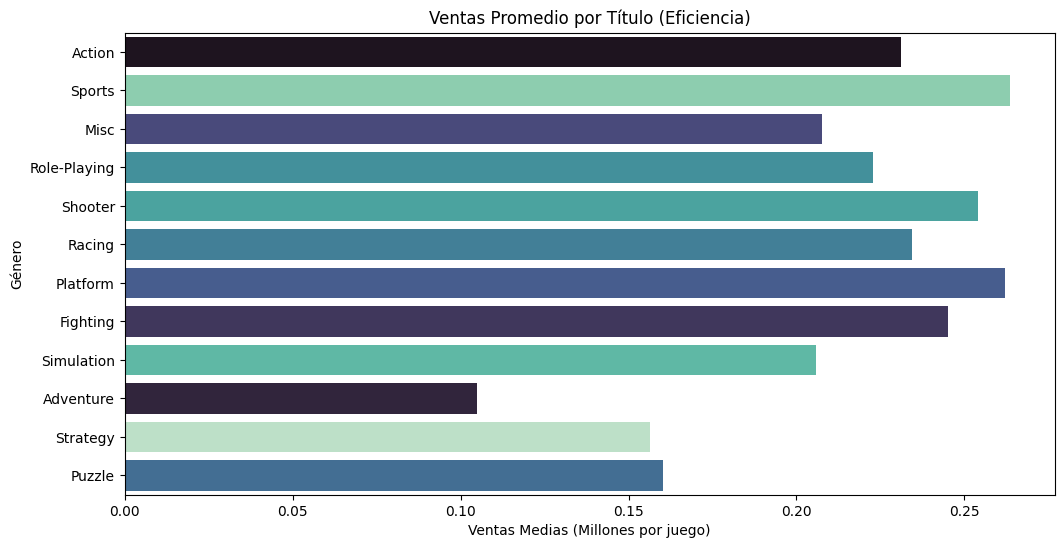

In [27]:
analizar_rendimiento_generos(df_clean)

El análisis por género mediante el gráfico de barras ofrece una visión más precisa de la eficiencia comercial en la industria. Se observa que, aunque los géneros de Acción y Shooters acumulan el mayor volumen de ventas totales, esto ocurre en un entorno de alta competitividad con un gran número de lanzamientos. En términos de eficiencia operativa (relación ventas por título publicado), el género de Deportes destaca como el más rentable. Por el contrario, los juegos de Estrategia presentan el menor rendimiento comercial por lanzamiento, situándose como el género con menor éxito relativo en la plataforma.

Gráfico guardado: ./src/img\evolucion_cuota_mercado_generos.jpg


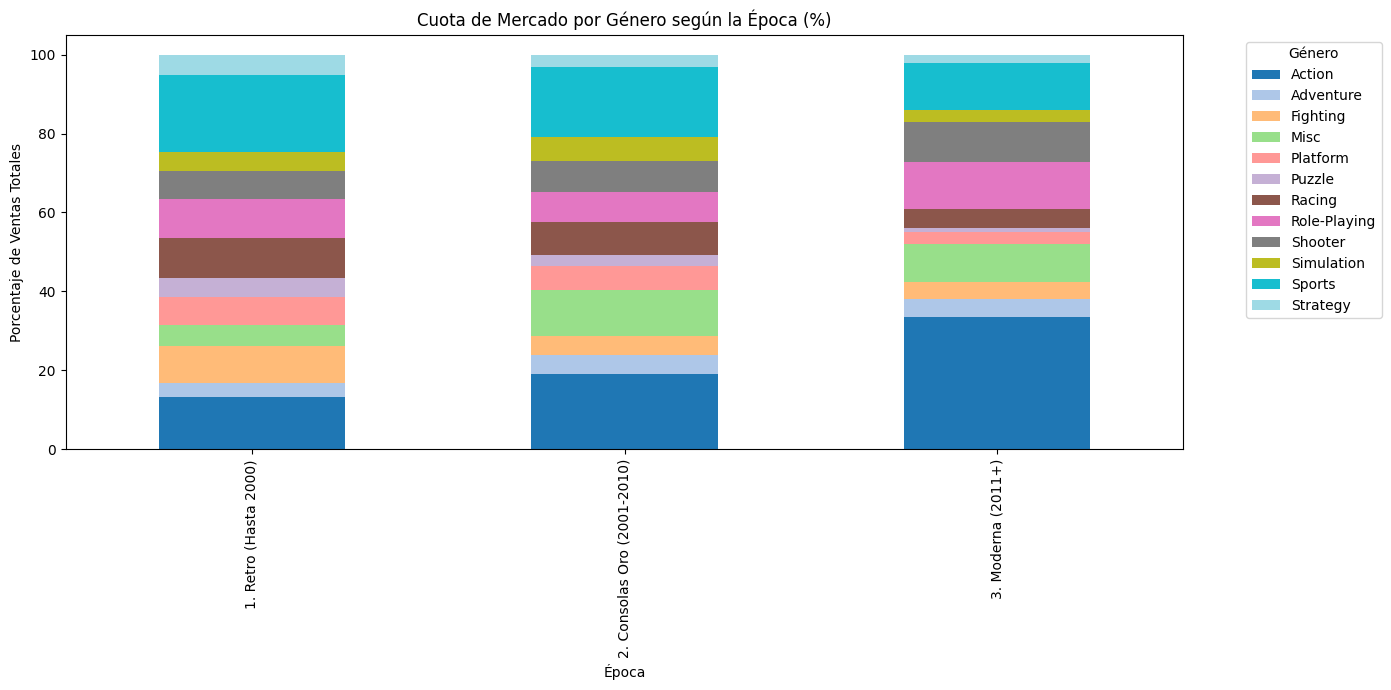

In [28]:
analizar_evolucion_cuota_mercado(df_clean)

Los datos son contundentes: Acción y Shooter son los reyes del mercado en volumen total. El gráfico de evolución por épocas muestra cómo el género Shooter ha dominado el mercado desde el año 2000, desplazando a géneros clásicos como las Plataformas o los Puzzles. Esto indica un cambio en el perfil del jugador hacia experiencias más competitivas, rápidas y orientadas al multijugador.

#### 3.4.2 Análisis del ciclo de vida de las top plataformas de videojuegos

Top 5 Plataformas analizadas: ['PS2', 'DS', 'PS3', 'X360', 'Wii']
Gráfico guardado: ./src/img\ciclo_vida_top_5_plataformas.jpg


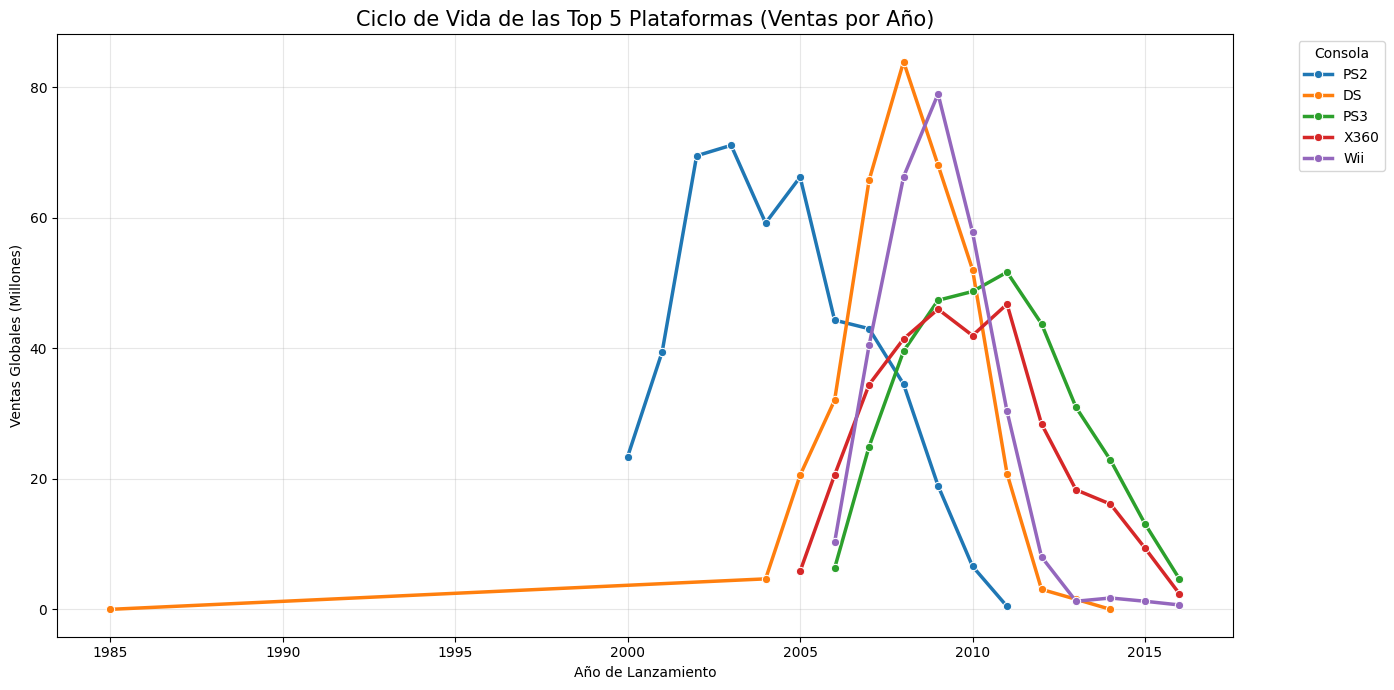

In [43]:
analizar_ciclo_vida_plataformas(df_clean, n_top=5)

Visualizamos claramente el ciclo de vida del hardware (aprox. 6-7 años). Las consolas como PS3 o X360 muestran curvas de campana casi perfectas: lanzamiento, auge, pico de madurez y declive rápido. La PS4 parece ser la plataforma qe empieza a crecer en ventas y relevancia en los últimos años, siendo esta plataforma una de las más indicadas para crear un videojuego, ya que parece haber un alto consumo en estos años atrás.

#### 3.4.3 Análisis de ventas de los top 10 publishers de videojuegos

--- Gráfico 1: Histórico ---
Gráfico guardado: ./src/img\top_10_publishers_Histórico_Completo.jpg


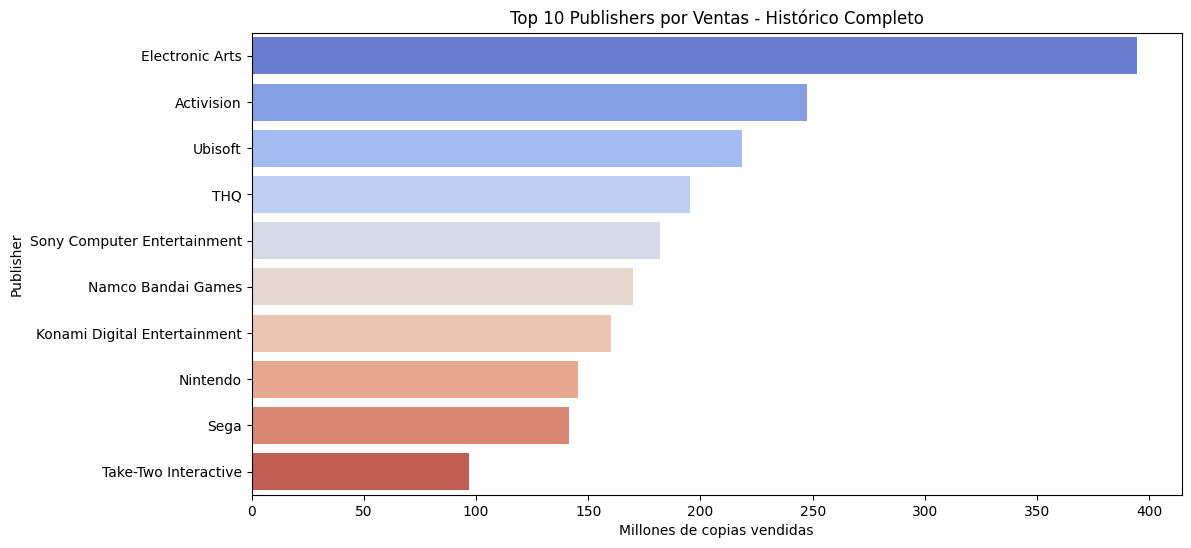

In [33]:
# Histórico completo (sin fechas)
print("--- Gráfico 1: Histórico ---")
analizar_top_publishers(df_clean)

El mercado presenta una estructura oligopólica. Unos pocos actores (Nintendo, Electronic Arts, Activision) concentran la gran mayoría de los ingresos globales. Esto implica altas barreras de entrada para nuevos estudios, que a menudo dependen de estos gigantes para la distribución y visibilidad.

--- Gráfico 2: Era Moderna ---
Gráfico guardado: ./src/img\top_10_publishers_Desde_2010.jpg


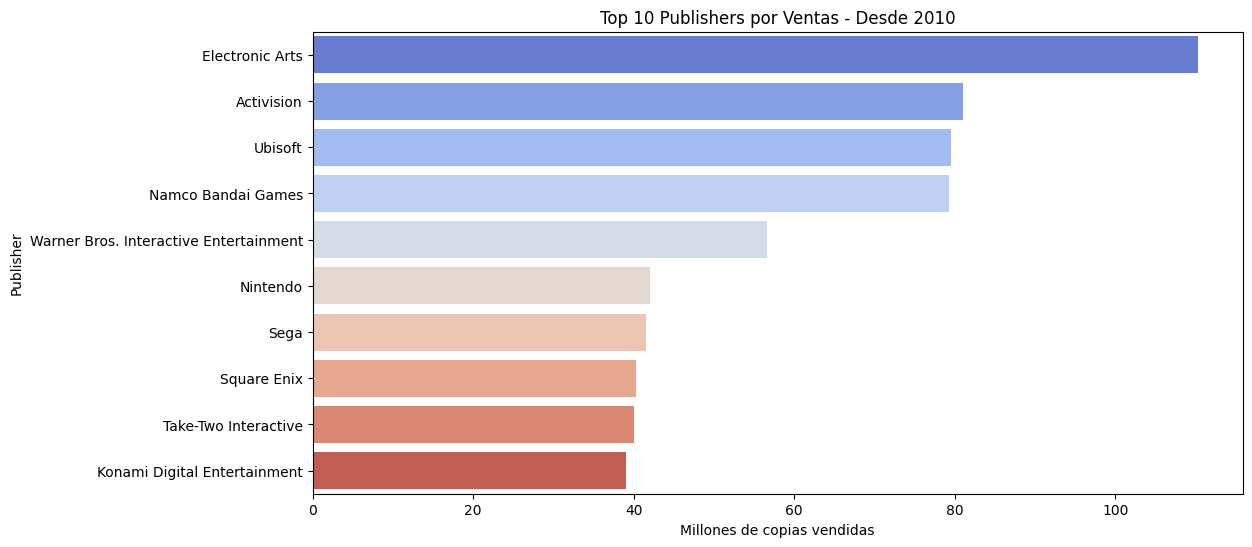

In [34]:
# Era moderna (2010 en adelante)
print("--- Gráfico 2: Era Moderna ---")
analizar_top_publishers(df_clean, start_year=2010)

Esas barreras que comentabamos las seguimos viendo en la era moderna, donde Electronic Arts sigue dominando el mercado, seguida de Activision y Ubisoft.

#### 3.4.4 Preferencias regionales (NA vs EU vs JP)

Primero analizamos que géneros y plataformas funcionan mejor en cada región


--- ANÁLISIS HISTÓRICO ---
[Norteamérica] Género líder: Action (372.6M)
[Norteamérica] Plataforma líder: DS (207.7M)
[Europa] Género líder: Action (189.9M)
[Europa] Plataforma líder: PS2 (122.9M)
[Japón] Género líder: Role-Playing (135.2M)
[Japón] Plataforma líder: PS2 (83.6M)
Gráfico guardado: ./src/img\lideres_regionales_Histórico.jpg


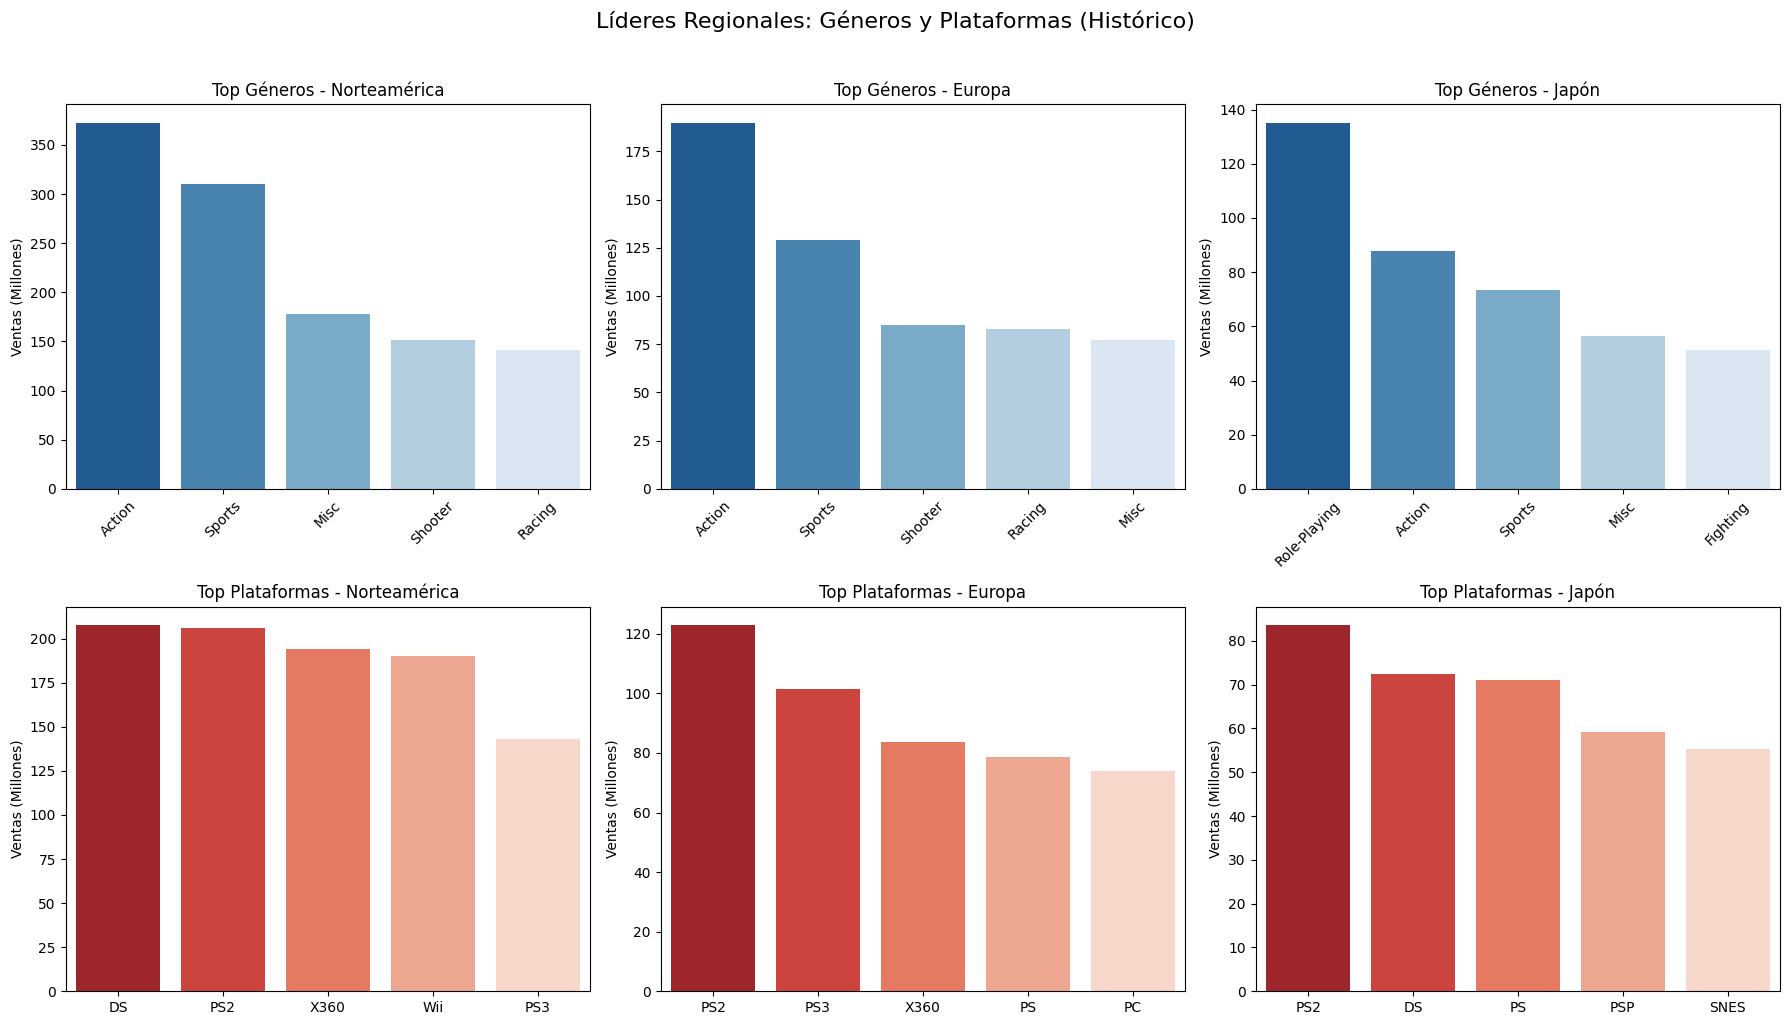

In [35]:
print("\n--- ANÁLISIS HISTÓRICO ---")
visualizar_lideres_regionales(df_clean)


--- ANÁLISIS RECIENTE (Desde 2010) ---
[Norteamérica] Género líder: Action (124.5M)
[Norteamérica] Plataforma líder: X360 (96.7M)
[Europa] Género líder: Action (93.8M)
[Europa] Plataforma líder: PS3 (65.2M)
[Japón] Género líder: Action (52.8M)
[Japón] Plataforma líder: PS3 (39.5M)
Gráfico guardado: ./src/img\lideres_regionales_Desde_2010.jpg


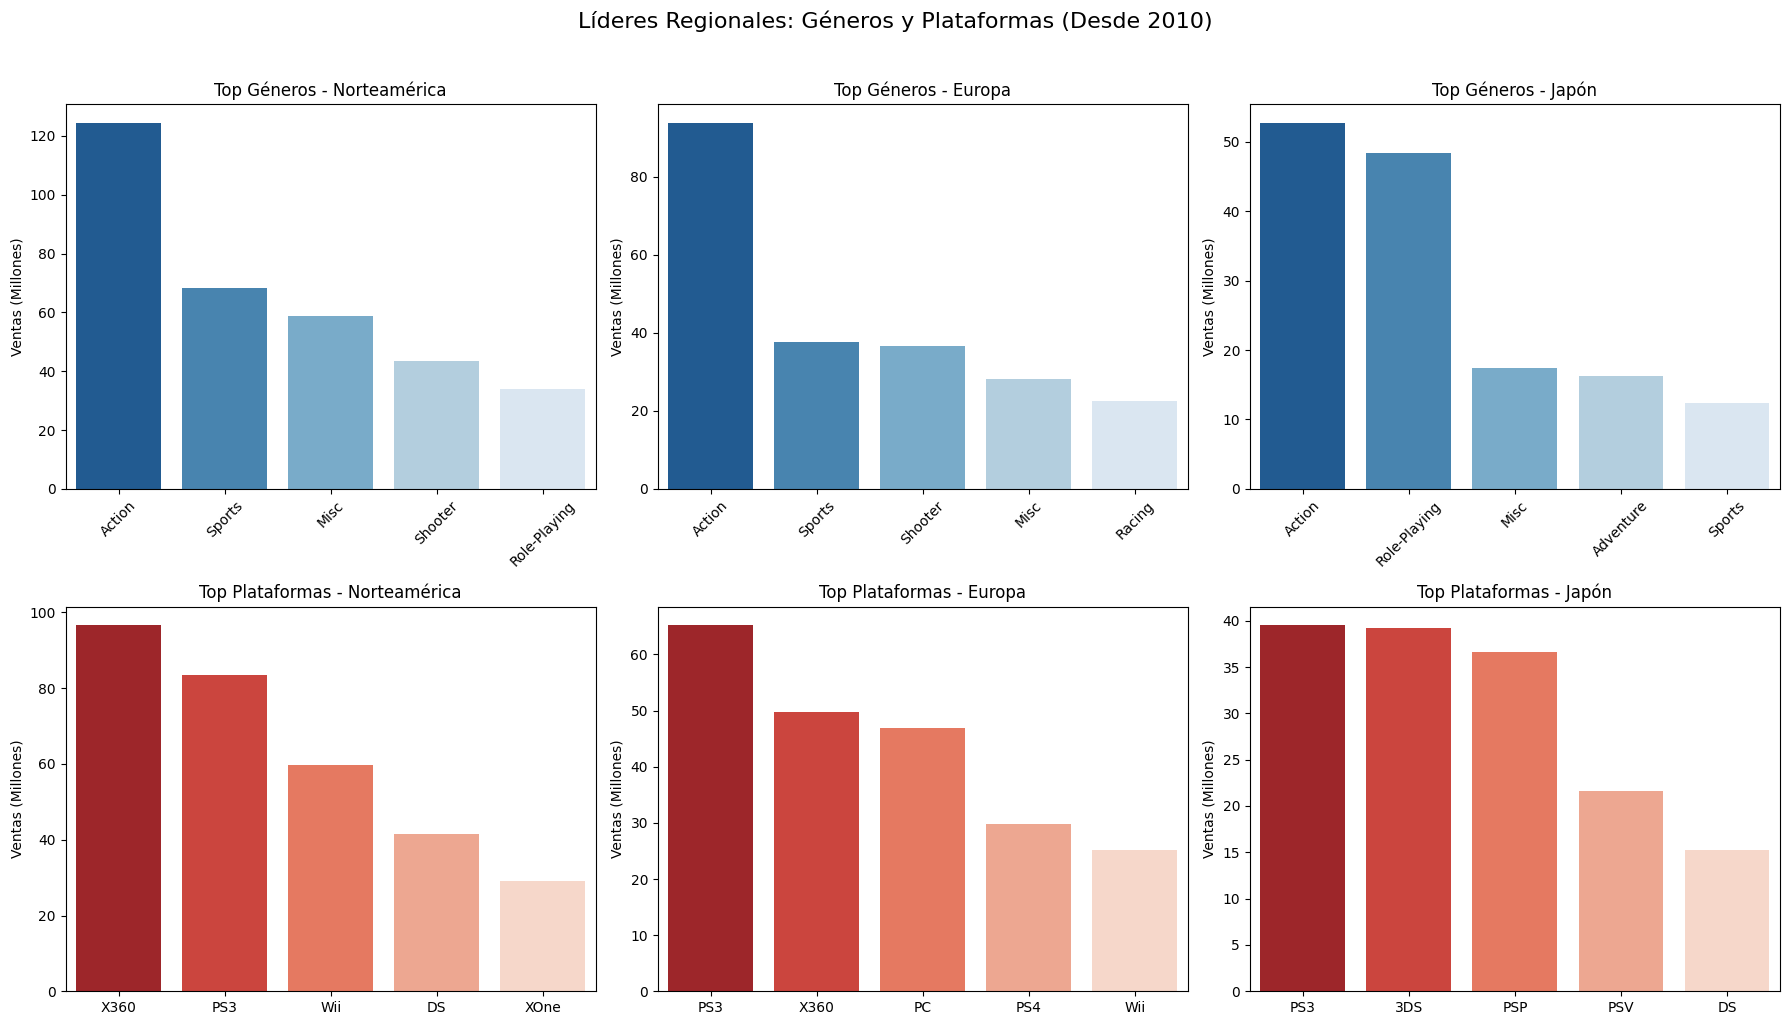

In [36]:
print("\n--- ANÁLISIS RECIENTE (Desde 2010) ---")
visualizar_lideres_regionales(df_clean, start_year=2010)

Se confirma una polarización extrema del mercado:

* Bloque Occidental (NA/EU): Homogéneo. Preferencia absoluta por Acción, Deportes y Shooters.

* Bloque Oriental (Japón): Mercado aislado. Dominio total del Rol (RPG). Conclusión: Una estrategia de "Talla única" no funciona. Para vender en Japón, es obligatorio localizar el contenido o desarrollar títulos específicos de RPG; exportar Shooters occidentales allí tiene una tasa de éxito histórica muy baja.

Segundo analizamos el efecto de adquirir el llamado ESRB (Entertainment Software Rating Board). Es un sistema que clasifica los videojuegos por edades y contenido:
* E (Everyone): Contenido apto para todos. Puede tener una violencia mínima y caricaturesca (como Mario).

* E10+ (Everyone 10+): Para mayores de 10 años. Un poco más de impacto o lenguaje suave.

* T (Teen): Para adolescentes. Puede incluir violencia, humor crudo o algo de sangre.

* M (Mature 17+): Para adultos. Violencia intensa, sangre fuerte, temas sexuales o lenguaje fuerte.


--- Contexto: Cantidad de juegos por Rating (Histórico) ---
Rating
E10+    182
E       220
M       666
T       590
Name: Global_Sales, dtype: int64
Gráfico guardado: ./src/img\ventas_media_rating_esrb_Histórico.jpg


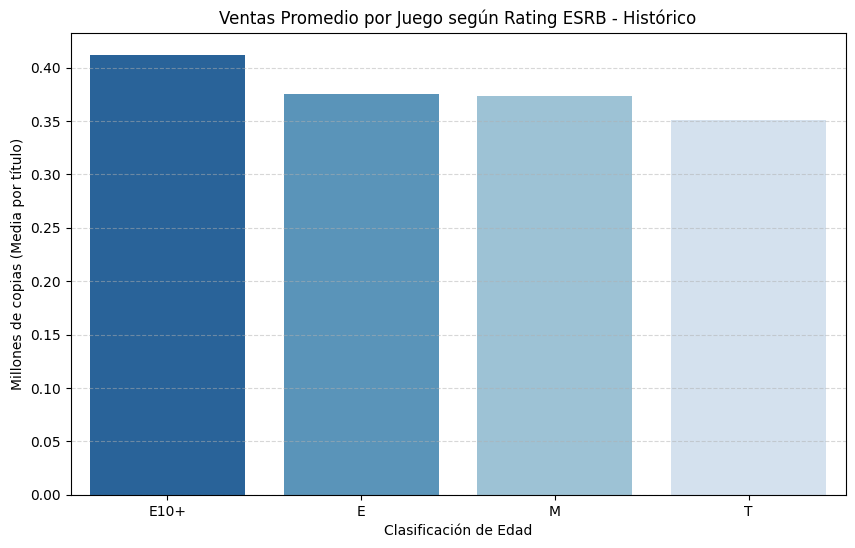

In [40]:
analizar_ventas_por_rating(df_filtrado)

Gráfico guardado: ./src/img\composicion_esrb_generos_Histórico.jpg


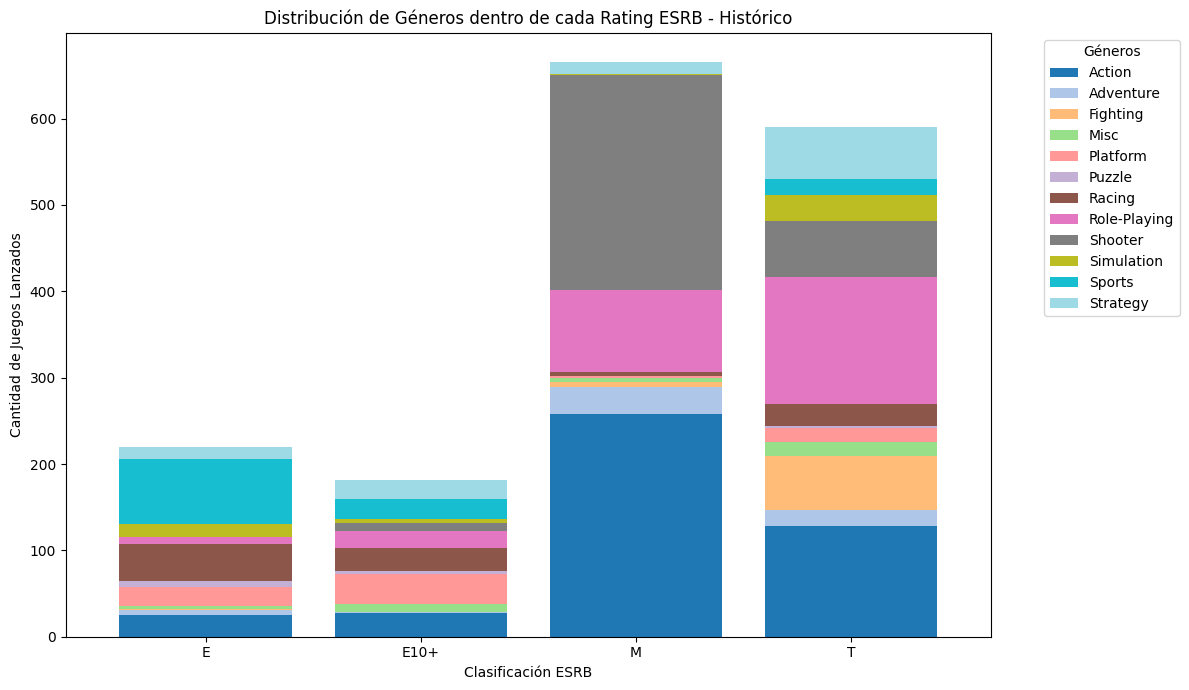

In [41]:
analizar_composicion_esrb_genero(df_filtrado)

Contraintuitivamente, la clasificación 'M' (Mature) no limita las ventas; al contrario, muchos de los mayores éxitos de la historia pertenecen a esta categoría. Esto destruye el mito de que los videojuegos son "juguetes para niños" y confirma que el grueso del mercado consumidor es adulto. La clasificación 'T' (Teen) muestra un desempeño inferior, quedándose en tierra de nadie.

## 4) **CONCLUSIONES FINALES**

Tras el análisis exhaustivo de los datos históricos de ventas (Global_Sales) y su cruce con métricas de calidad y demografía, presentamos las siguientes directrices para la toma de decisiones:

**Calidad y Marketing: El "Efecto Crítico"**

Los datos demuestran que la industria del videojuego sigue un modelo de "Gatekeepers". La correlación entre Critic_Score y ventas es significativamente superior a la opinión del usuario. La inversión en Calidad y en relaciones públicas para asegurar una buena recepción de la prensa especializada es tan crítica como el propio desarrollo. Un juego con un Metascore < 70 tiene probabilidades drásticamente menores de recuperar la inversión, independientemente de cuánto le guste a un nicho de usuarios.

**Geostrategia: La Barrera Cultural**

No existe un "Mercado Global" homogéneo. Hemos identificado dos bloques desconectados: 
* Occidente (NA/EU): Un mercado saturado dominado por la adrenalina (Shooters, Deportes, Acción). Aquí, la competencia es feroz y requiere grandes presupuestos de marketing.

* Japón (JP): Un mercado insular fiel al Role-Playing (RPG).

Si el presupuesto es limitado, es más seguro atacar un nicho específico (RPG) en Japón. Si se busca un blockbuster mundial, el género de Acción/Aventura es obligatorio, pero requiere competir contra gigantes establecidos.

**Timing de Lanzamiento: La Ventana de Oportunidad**

El análisis del ciclo de vida de las plataformas (PS2, PS3, X360) revela un "momento de oro" entre el 3º y 5º año de vida de una consola. Aún así ofrece un riesgo: Lanzar al inicio del ciclo (año 1-2) limita las ventas por la baja base instalada de consolas. Lanzar al final (año 7+) arriesga la irrelevancia tecnológica. Una posible estrategia: Alinear el roadmap de desarrollo para lanzar el título cuando la penetración de mercado de la consola actual (ej. PS5/Switch) esté en su pico de madurez.

**Demografía: El Mito de la Edad**

La clasificación 'M' (Mature 17+) no es un limitante comercial; de hecho, agrupa a muchos de los títulos más rentables de la historia. El perfil del "gamer" ha envejecido. Diseñar narrativas complejas y adultas no reduce el mercado potencial, al contrario, apela al segmento con mayor poder adquisitivo.